In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [155]:
M22 = pd.read_csv('../../data/M4_obs_Howell_pbjam_lum_vary.csv')

S19 = pd.read_csv('../../data/Stetson-2019-phot-data.csv')

S19 = S19.reset_index()

pos = pd.read_csv('../../data/M22-RA-DEC.csv')

M22 = M22.merge(pos, on = 'Gaia_source_ID_DR3')

In [156]:
for i in range(len(S19)):
    expandRA = S19.loc[i, 'RAJ2000'].split()
    expandDEC = S19.loc[i, 'DEJ2000'].split()
    ra = f'{expandRA[0]}h{expandRA[1]}m{expandRA[2]}s'
    dec = f'{expandDEC[0]}d{expandDEC[1]}m{expandDEC[2]}s'
    coords = SkyCoord(ra, dec)
    S19.loc[i, 'RA'] = coords.ra.deg
    S19.loc[i, 'DEC'] = coords.dec.deg
    

In [157]:
M22S19 = M22.copy()

In [158]:
for v in M22.index: 
    i = ((S19['RA']-M22.loc[v, 'RA'])**2 + \
       (S19['DEC']-M22.loc[v, 'Dec'])**2).abs().idxmin()

    M22S19.loc[v, 'RA_S19'] = S19.loc[i, 'RA']
    M22S19.loc[v, 'DEC_S19'] = S19.loc[i, 'DEC']
    M22S19.loc[v, 'Umag'] = S19.loc[i, 'Umag']
    M22S19.loc[v, 'e_Umag'] = S19.loc[i, 'e_Umag']
    M22S19.loc[v, 'Bmag'] = S19.loc[i, 'Bmag']
    M22S19.loc[v, 'e_Bmag'] = S19.loc[i, 'e_Bmag']
    M22S19.loc[v, 'Imag'] = S19.loc[i, 'Imag']
    M22S19.loc[v, 'e_Imag'] = S19.loc[i, 'e_Imag']
    M22S19.loc[v, 'Vmag'] = S19.loc[i, 'Vmag']
    M22S19.loc[v, 'e_Vmag'] = S19.loc[i, 'e_Vmag']

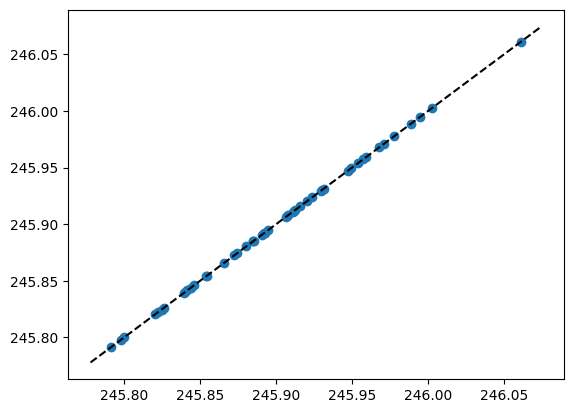

In [159]:
ax = plt.gca()
plt.scatter(M22S19['RA'], M22S19['RA_S19'])
plt.plot(np.linspace(ax.get_xlim()[0], ax.get_xlim()[1]), np.linspace(ax.get_xlim()[0], ax.get_xlim()[1]), color = 'black', linestyle = '--')

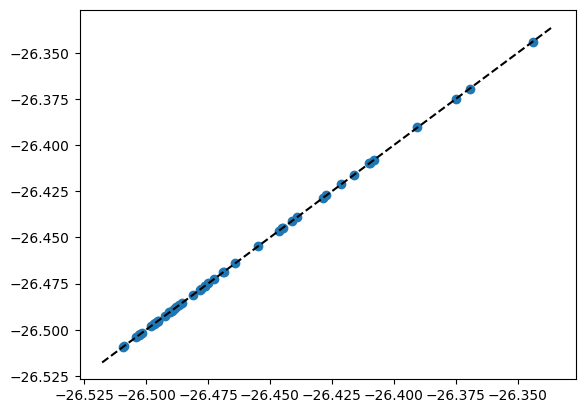

In [160]:
ax = plt.gca()
plt.scatter(M22S19['Dec'], M22S19['DEC_S19'])
plt.plot(np.linspace(ax.get_xlim()[0], ax.get_xlim()[1]), np.linspace(ax.get_xlim()[0], ax.get_xlim()[1]), color = 'black', linestyle = '--')

In [161]:
M22S19['UB'] = M22S19['Umag'] - M22S19['Bmag']
M22S19['BI'] = M22S19['Bmag'] - M22S19['Imag']
M22S19['CUBI'] = M22S19['UB'] - M22S19['BI']

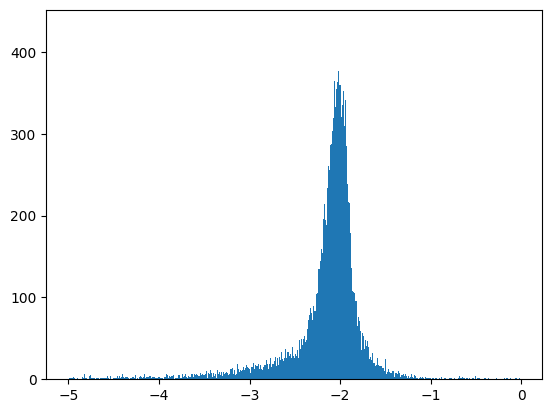

In [170]:
UB = S19[(S19['Umag'] > 0)&(S19['Bmag'] > 0)]['Umag'] - S19[(S19['Umag'] > 0)&(S19['Bmag'] > 0)]['Bmag']
BI = S19[(S19['Umag'] > 0)&(S19['Bmag'] > 0)]['Bmag'] - S19[(S19['Umag'] > 0)&(S19['Bmag'] > 0)]['Imag']
CUBI = UB - BI
plt.hist(CUBI[(CUBI > -5)&(CUBI < 0)], bins = 1000)
plt.show()

(-2.3, -1.8)

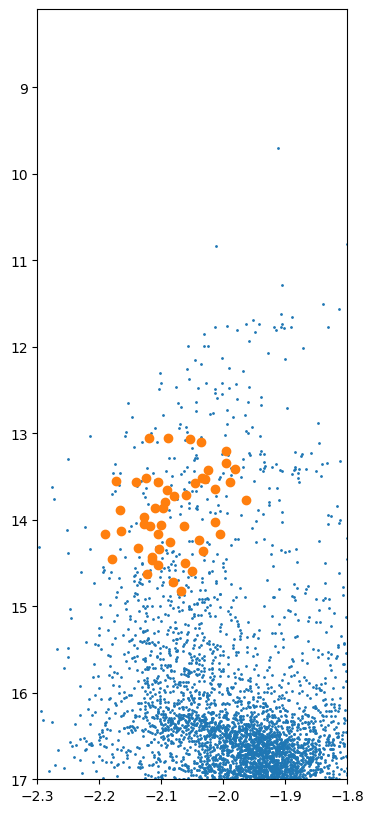

In [163]:
fig = plt.figure(figsize = (4,10))
ax = plt.gca()
plt.scatter(CUBI, S19[(S19['Umag'] > 0)&(S19['Bmag'] > 0)]['Vmag'], s = 1)
plt.scatter(M22S19['CUBI'], M22S19['Vmag'])
ax.invert_yaxis()
ax.set_ylim(17, )
ax.set_xlim(-2.3, -1.8)

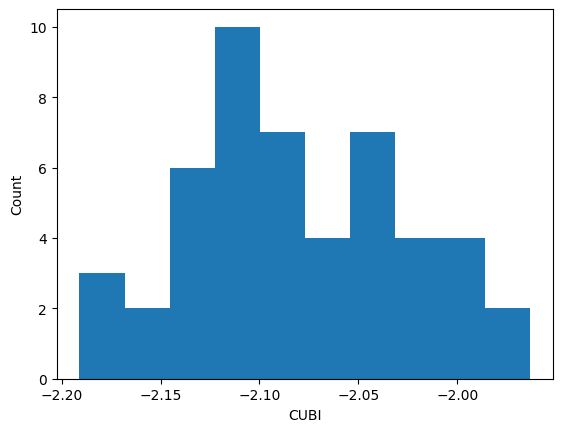

In [172]:
plt.hist(M22S19['CUBI'])
plt.xlabel('CUBI')
plt.ylabel('Count')
plt.savefig('../../figs/CUBI-M4.png', bbox_inches = 'tight')